In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-meas',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_meas',
        '--data_nsample', '144',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',
        '--target_ndim', '1',

        '--feature_dim', '0,1',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '128',
        '--nlayer_stat', '3',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.702091, valid=0.498555, test=0.501682
	validation loss decreased (inf -> 0.498555), saving model ...
	epoch 2 losses: train=1.162396, valid=0.255338, test=0.248944
	validation loss decreased (0.498555 -> 0.255338), saving model ...
	epoch 3 losses: train=0.738351, valid=0.218836, test=0.217265
	validation loss decreased (0.255338 -> 0.218836), saving model ...
	epoch 4 losses: train=0.671655, valid=0.210078, test=0.203008
	validation loss decreased (0.218836 -> 0.210078), saving model ...
	epoch 5 losses: train=0.641551, valid=0.203733, test=0.197581
	validation loss decreased (0.210078 -> 0.203733), saving model ...
	epoch 6 losses: train=0.579831, valid=0.171802, test=0.170884
	validation loss decreased (0.203733 -> 0.171802), saving model ...
	epoch 7 losses: train=0.506428, valid=0.163479, test=0.157536
	validation loss decreased (0.171802 -> 0.163479), saving model ...
	epoch 8 losses: train=0.492051, valid=0.158802, test=0.15

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

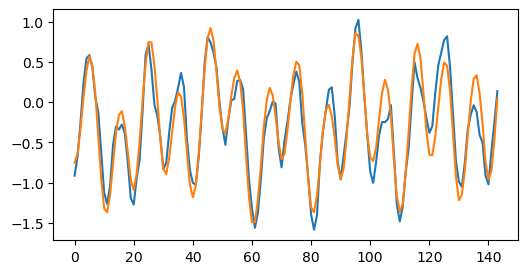

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.466349, valid=0.386201, test=0.344606
	validation loss decreased (inf -> 0.386201), saving model ...
	epoch 2 losses: train=0.376793, valid=0.373855, test=0.336770
	validation loss decreased (0.386201 -> 0.373855), saving model ...
	epoch 3 losses: train=0.369144, valid=0.369560, test=0.332929
	validation loss decreased (0.373855 -> 0.369560), saving model ...
	epoch 4 losses: train=0.364992, valid=0.361623, test=0.328217
	validation loss decreased (0.369560 -> 0.361623), saving model ...
	epoch 5 losses: train=0.362373, valid=0.356879, test=0.324993
	validation loss decreased (0.361623 -> 0.356879), saving model ...
	epoch 6 losses: train=0.357909, valid=0.355126, test=0.324580
	validation loss decreased (0.356879 -> 0.355126), saving model ...
	epoch 7 losses: train=0.352278, valid=0.345630, test=0.315908
	validation loss decreased (0.355126 -> 0.345630), saving model ...
	epoch 8 losses: train=0.345279, valid=0.340768, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

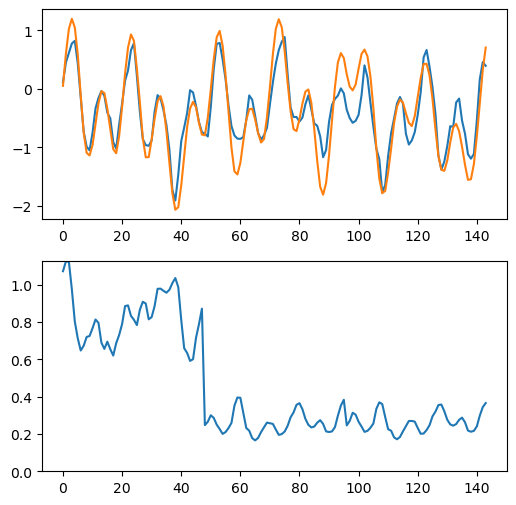

In [9]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.480382, valid=0.851321, test=0.844635
	validation loss decreased (inf -> 0.851321), saving model ...
	epoch 2 losses: train=0.844762, valid=0.492296, test=0.495359
	validation loss decreased (0.851321 -> 0.492296), saving model ...
	epoch 3 losses: train=0.661386, valid=0.433100, test=0.432067
	validation loss decreased (0.492296 -> 0.433100), saving model ...
	epoch 4 losses: train=0.523160, valid=0.348036, test=0.349892
	validation loss decreased (0.433100 -> 0.348036), saving model ...
	epoch 5 losses: train=0.432130, valid=0.304627, test=0.303735
	validation loss decreased (0.348036 -> 0.304627), saving model ...
	epoch 6 losses: train=0.397055, valid=0.283929, test=0.282030
	validation loss decreased (0.304627 -> 0.283929), saving model ...
	epoch 7 losses: train=0.375629, valid=0.275476, test=0.272942
	validation loss decreased (0.283929 -> 0.275476), saving model ...
	epoch 8 losses: train=0.360141, valid=0.271068, test=0.269

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

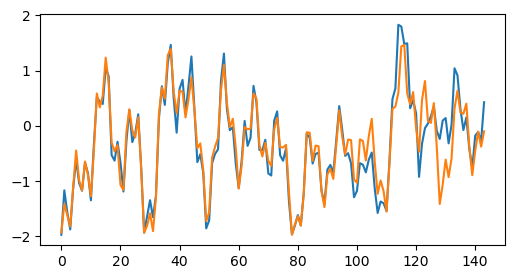

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.205893, valid=-0.045617, test=-0.000884
	validation loss decreased (inf -> -0.045617), saving model ...
	epoch 2 losses: train=-0.111925, valid=-0.076261, test=-0.026921
	validation loss decreased (-0.045617 -> -0.076261), saving model ...
	epoch 3 losses: train=-0.126502, valid=0.220729, test=0.252417
	early stopping counter: 1 out of 30
	epoch 4 losses: train=-0.065641, valid=-0.108724, test=-0.062208
	validation loss decreased (-0.076261 -> -0.108724), saving model ...
	epoch 5 losses: train=-0.207867, valid=-0.134168, test=-0.092735
	validation loss decreased (-0.108724 -> -0.134168), saving model ...
	epoch 6 losses: train=-0.263279, valid=-0.209176, test=-0.168514
	validation loss decreased (-0.134168 -> -0.209176), saving model ...
	epoch 7 losses: train=-0.310111, valid=-0.226214, test=-0.180380
	validation loss decreased (-0.209176 -> -0.226214), saving model ...
	epoch 8 losses: train=-0.343451, valid=-0.289035, tes

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

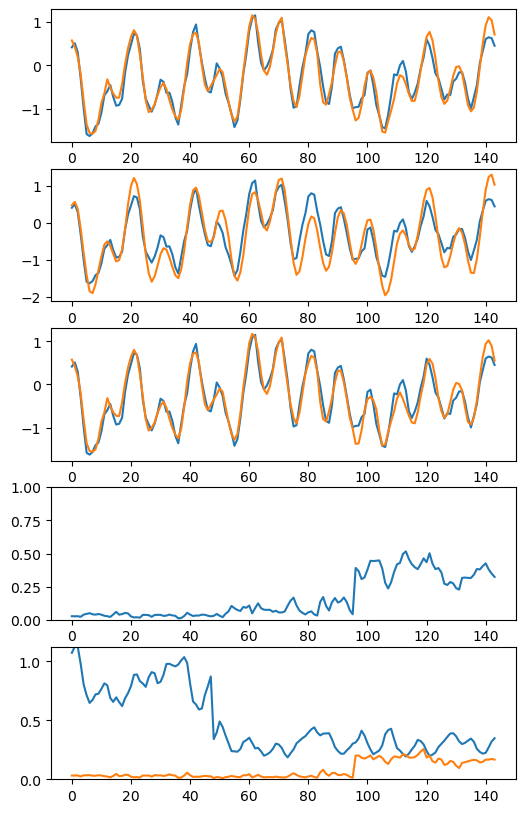

In [15]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break